<a href="https://colab.research.google.com/github/swirita/salmonellosis-forecasting-analysis/blob/main/notebooks/04_salmonellosis_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest forecasting of MMWR weekly cases

## Scenario

We want to forecast **`Current week` cases** for future MMWR weeks.

Synthetic data contains:
- 2022–2025: complete historical years
- 2026: observed through **MMWR Week 37**
- 2026 Weeks 38–52: unknown future values that we will forecast

The target is:

**`Current week`**

The model uses only information that would be available when making the forecast.


In [14]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import os
import matplotlib.pyplot as plt


## Load and Prepare Data

In [2]:
# Connect Google Colab to Google Drive
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
# Project folders
project_folder = "/content/drive/MyDrive/Salmonellosis Forecasting and Analysis"
data_folder = os.path.join(project_folder, "data")

# Load the cleaned data created in the preparation notebook
cleaned_file_path = os.path.join(data_folder, "salmonellosis_weekly_cleaned.csv")
df = pd.read_csv(cleaned_file_path)

df = df.sort_values(
    ["Reporting Area", "Current MMWR Year", "MMWR WEEK"]
).reset_index(drop=True)

df.head()

,Reporting Area,Current MMWR Year,MMWR WEEK,Label,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2022,1,Salmonellosis (excluding Salmonella Typhi infe...,10,38.0,10,6.0,Winter,2.0
1,ALABAMA,2022,2,Salmonellosis (excluding Salmonella Typhi infe...,3,38.0,18,12.0,Winter,10.0
2,ALABAMA,2022,3,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,24,17.0,Winter,3.0
3,ALABAMA,2022,4,Salmonellosis (excluding Salmonella Typhi infe...,2,38.0,26,25.0,Winter,0.0
4,ALABAMA,2022,5,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,29,30.0,Winter,2.0


## 1. Understand the prediction problem

For example, for Alabama Week 38 of 2026:

**Known before Week 38**
- Reporting Area
- MMWR Year
- MMWR Week
- Previous week cases (Week 37)
- Previous 52-week maximum
- Cumulative YTD of 2025 through Week 38
- Season

**Unknown**
- Current week cases in Week 38

So the model learns:

`Historical information → Current week cases`


## 2. Important leakage rule

Do **not** calculate the rolling maximum using the current target week.

Correct:

`shift(1) → rolling(52)`

Incorrect:

`rolling(52)`

The shift makes sure Week 38's target cannot enter its own predictor.


In [4]:
# Recreate the leakage-safe rolling maximum if needed
df["Previous 52 week Max"] = (
    df.groupby("Reporting Area")["Current week"]
      .transform(
          lambda s: s.shift(1).rolling(52, min_periods=1).max()
      )
)

df["Previous week cases"] = (
    df.groupby("Reporting Area")["Current week"].shift(1)
)


## 3. Define features and target


In [5]:
target = "Current week"

features = [
    "Reporting Area",
    "Current MMWR Year",
    "MMWR WEEK",
    "Previous 52 week Max",
    "Cumulative YTD Previous MMWR Year",
    "Season",
    "Previous week cases"
]

df_model = df.dropna(
    subset=features + [target]
).copy()

X = df_model[features]
y = df_model[target]


## 4. Use the Same 15-Week Validation Window as SARIMA

To compare the models fairly:

- Train through 2025 Week 37.
- Keep 2025 Weeks 38–52 unseen.
- Forecast those 15 weeks recursively.

The model cannot use the actual previous-week cases from inside the unseen window. After Week 38, it must use its own earlier prediction.

In [6]:
VALIDATION_YEAR = 2025
VALIDATION_LAST_OBSERVED_WEEK = 37
VALIDATION_FIRST_FORECAST_WEEK = 38
VALIDATION_LAST_FORECAST_WEEK = 52

train = df_model[
    (df_model["Current MMWR Year"] < VALIDATION_YEAR)
    | (
        (df_model["Current MMWR Year"] == VALIDATION_YEAR)
        & (df_model["MMWR WEEK"] <= VALIDATION_LAST_OBSERVED_WEEK)
    )
].copy()

validation_actual = df_model[
    (df_model["Current MMWR Year"] == VALIDATION_YEAR)
    & df_model["MMWR WEEK"].between(
        VALIDATION_FIRST_FORECAST_WEEK,
        VALIDATION_LAST_FORECAST_WEEK,
    )
][
    ["Reporting Area", "Current MMWR Year", "MMWR WEEK", target]
].copy()

print("Training rows:", len(train))
print("Validation rows:", len(validation_actual))
print("Validation areas:", validation_actual["Reporting Area"].nunique())

Training rows: 13439
Validation rows: 1050
Validation areas: 70


## 5. Preprocess categorical variables

Random Forest needs numeric inputs.

We one-hot encode:
- Reporting Area
- Season

The numeric variables pass through unchanged.


In [7]:
categorical_features = [
    "Reporting Area",
    "Season"
]

numeric_features = [
    "Current MMWR Year",
    "MMWR WEEK",
    "Previous 52 week Max",
    "Cumulative YTD Previous MMWR Year",
    "Previous week cases"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop='first'),
            categorical_features
        )
    ],
    remainder="passthrough"
)


## 6. Train the Random Forest


In [8]:
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("random_forest", rf)
    ]
)

model.fit(
    train[features],
    train[target]
)


/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Reporting Area',
                                                   'Season'])])),
                ('random_forest',
                 RandomForestRegressor(max_depth=12, min_samples_leaf=2,
                                       n_estimators=400, n_jobs=-1,
                                       random_state=42))])

## 7. Evaluate Recursively on Unseen 2025 Weeks 38–52

This recreates the real forecasting situation. Week 38 starts from known history; each later week's lag features are updated with the model's earlier predictions.

In [9]:
validation_history = {}

for area in sorted(validation_actual["Reporting Area"].unique()):
    area_history = df[
        (df["Reporting Area"] == area)
        & (
            (df["Current MMWR Year"] < VALIDATION_YEAR)
            | (
                (df["Current MMWR Year"] == VALIDATION_YEAR)
                & (df["MMWR WEEK"] <= VALIDATION_LAST_OBSERVED_WEEK)
            )
        )
    ].sort_values(["Current MMWR Year", "MMWR WEEK"])

    validation_history[area] = list(
        area_history["Current week"].dropna().astype(float)
    )

validation_forecast_rows = []

for area in validation_history:
    for week in range(
        VALIDATION_FIRST_FORECAST_WEEK,
        VALIDATION_LAST_FORECAST_WEEK + 1,
    ):
        known_row = df[
            (df["Reporting Area"] == area)
            & (df["Current MMWR Year"] == VALIDATION_YEAR)
            & (df["MMWR WEEK"] == week)
        ]

        if known_row.empty or not validation_history[area]:
            continue

        known_row = known_row.iloc[0]
        previous_week_cases = validation_history[area][-1]
        previous_52_max = max(validation_history[area][-52:])

        row = pd.DataFrame([{
            "Reporting Area": area,
            "Current MMWR Year": VALIDATION_YEAR,
            "MMWR WEEK": week,
            "Previous 52 week Max": previous_52_max,
            "Cumulative YTD Previous MMWR Year": known_row[
                "Cumulative YTD Previous MMWR Year"
            ],
            "Season": known_row["Season"],
            "Previous week cases": previous_week_cases,
        }])

        prediction = float(model.predict(row[features])[0])
        prediction = max(prediction, 0)
        validation_history[area].append(prediction)

        validation_forecast_rows.append({
            "Reporting Area": area,
            "Current MMWR Year": VALIDATION_YEAR,
            "MMWR WEEK": week,
            "Forecast Current week": prediction,
        })

rf_validation_predictions = pd.DataFrame(validation_forecast_rows).merge(
    validation_actual,
    on=["Reporting Area", "Current MMWR Year", "MMWR WEEK"],
    how="inner",
)

mae = mean_absolute_error(
    rf_validation_predictions[target],
    rf_validation_predictions["Forecast Current week"],
)
rmse = mean_squared_error(
    rf_validation_predictions[target],
    rf_validation_predictions["Forecast Current week"],
) ** 0.5
r2 = r2_score(
    rf_validation_predictions[target],
    rf_validation_predictions["Forecast Current week"],
)

print(f"Evaluated areas: {rf_validation_predictions['Reporting Area'].nunique()}")
print(f"Validation predictions: {len(rf_validation_predictions):,}")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

rf_validation_predictions.head()

Evaluated areas: 70
Validation predictions: 1,050
MAE : 9.15
RMSE: 32.19
R²  : 0.902


,Reporting Area,Current MMWR Year,MMWR WEEK,Forecast Current week,Current week
0,ALABAMA,2025,38,11.319583,20
1,ALABAMA,2025,39,13.839031,16
2,ALABAMA,2025,40,7.168700,15
3,ALABAMA,2025,41,9.023133,12
4,ALABAMA,2025,42,9.670814,7


### How to Interpret This Comparison

These metrics now measure a true 15-week future forecast, not a one-week prediction that receives the real previous week's value.

- **MAE:** average number of cases the forecast misses by
- **RMSE:** gives more weight to large misses
- **R²:** compares how much variation the model explains

Use the SARIMA metrics from the same 2025 Weeks 38–52 window. The lower MAE/RMSE and higher R² indicate the stronger model for this forecasting task.

## 8. Retrain using all information available up to 2026 Week 37

Now that we have evaluated the modeling approach on 2025, we can use:

- 2022
- 2023
- 2024
- 2025
- 2026 Weeks 1–37

to train the final model.

We still do not use Weeks 38–52 because those are the future periods we want to forecast.


In [10]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "random_forest",
            RandomForestRegressor(
                n_estimators=500,
                max_depth=14,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

final_model.fit(
    df_model[features],
    df_model[target]
)


/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Reporting Area',
                                                   'Season'])])),
                ('random_forest',
                 RandomForestRegressor(max_depth=14, min_samples_leaf=2,
                                       n_estimators=500, n_jobs=-1,
                                       random_state=42))])

## 9. Recursive forecasting of 2026 Weeks 38–52

This is the key part.

For Week 38:
- Previous week cases = actual Week 37 cases

For Week 39:
- Previous week cases = **predicted Week 38 cases**

For Week 40:
- Previous week cases = **predicted Week 39 cases**

and so on.

This is called **recursive / autoregressive forecasting**.


In [11]:
# Previous-year cumulative YTD lookup.
# For forecasting 2026, use the actual cumulative 2025 values.
ytd_lookup = (
    df[df["Current MMWR Year"] == 2025]
    .set_index(["Reporting Area", "MMWR WEEK"])
    ["Cumulative YTD Current MMWR Year"]
)

# Keep a history of observed cases.
history = {}

for area in df["Reporting Area"].unique():
    area_df = df[
        df["Reporting Area"] == area
    ].sort_values(
        ["Current MMWR Year", "MMWR WEEK"]
    )

    history[area] = list(
        area_df["Current week"].astype(float)
    )

forecast_rows = []

for area in history:

    for week in range(38, 53):

        # 1. Previous week's cases
        previous_week_cases = history[area][-1]

        # 2. Maximum of the previous 52 weeks
        previous_52_max = max(history[area][-52:])

        # 3. Previous year's YTD at the same MMWR week
        previous_year_ytd = ytd_lookup.loc[(area, week)]

        # 4. Determine season
        if week <= 13:
            season = "Winter"
        elif week <= 26:
            season = "Spring"
        elif week <= 39:
            season = "Summer"
        else:
            season = "Fall"

        row = pd.DataFrame([{
            "Reporting Area": area,
            "Current MMWR Year": 2026,
            "MMWR WEEK": week,
            "Previous 52 week Max": previous_52_max,
            "Cumulative YTD Previous MMWR Year": previous_year_ytd,
            "Season": season,
            "Previous week cases": previous_week_cases
        }])

        # 5. Predict the current week
        prediction = float(
            final_model.predict(row[features])[0]
        )

        prediction = max(prediction, 0)

        # 6. Store prediction so it becomes
        #    the previous week for the next forecast
        history[area].append(prediction)

        forecast_rows.append({
            "Reporting Area": area,
            "Current MMWR Year": 2026,
            "MMWR WEEK": week,
            "Forecast Current week": prediction,
            "Previous 52 week Max": previous_52_max,
            "Cumulative YTD Previous MMWR Year": previous_year_ytd,
            "Season": season,
            "Previous week cases": previous_week_cases
        })

forecast = pd.DataFrame(forecast_rows)

forecast.head(10)


,Reporting Area,Current MMWR Year,MMWR WEEK,Forecast Current week,Previous 52 week Max,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2026,38,12.288650,20.0,753,Summer,16.000000
1,ALABAMA,2026,39,11.607967,20.0,802,Summer,12.288650
2,ALABAMA,2026,40,10.254732,20.0,849,Fall,11.607967
3,ALABAMA,2026,41,9.741864,20.0,872,Fall,10.254732
4,ALABAMA,2026,42,9.778757,20.0,892,Fall,9.741864
5,ALABAMA,2026,43,9.788661,20.0,958,Fall,9.778757
6,ALABAMA,2026,44,9.729451,20.0,975,Fall,9.788661
7,ALABAMA,2026,45,9.677655,20.0,997,Fall,9.729451
8,ALABAMA,2026,46,9.558747,20.0,1030,Fall,9.677655
9,ALABAMA,2026,47,8.703629,20.0,1050,Fall,9.558747


## 10. Forecast all future weeks

The resulting table contains forecasts for:

**2026 Week 38 → Week 52**

for each reporting area.


In [12]:
forecast

,Reporting Area,Current MMWR Year,MMWR WEEK,Forecast Current week,Previous 52 week Max,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2026,38,12.288650,20.0,753,Summer,16.000000
1,ALABAMA,2026,39,11.607967,20.0,802,Summer,12.288650
2,ALABAMA,2026,40,10.254732,20.0,849,Fall,11.607967
3,ALABAMA,2026,41,9.741864,20.0,872,Fall,10.254732
4,ALABAMA,2026,42,9.778757,20.0,892,Fall,9.741864
...,...,...,...,...,...,...,...,...
1045,WYOMING,2026,48,3.848494,10.0,109,Fall,4.023293
1046,WYOMING,2026,49,3.801795,10.0,112,Fall,3.848494
1047,WYOMING,2026,50,3.913654,10.0,113,Fall,3.801795
1048,WYOMING,2026,51,3.858662,10.0,113,Fall,3.913654


## 11. Important: why we do NOT use Current YTD

If `Current YTD` includes the current week's cases, it contains the target.

For example:

`Week 20 Current YTD = Weeks 1–20 total`

But the Week 20 target is:

`Cases in Week 20`

Therefore, Week 20's Current YTD contains Week 20's target and creates leakage.

A safe alternative is a previous-week YTD:

`YTD through Week 19 → predict Week 20`

Your `Cumulative YTD Previous MMWR Year` is different and can be used because it comes from the previous year.


## 12. Compare actual 2026 observations with forecasts

In a real project, you can plot:

- Actual cases: Weeks 1–37
- Forecast cases: Weeks 38–52

The forecast begins exactly where the observed data ends.


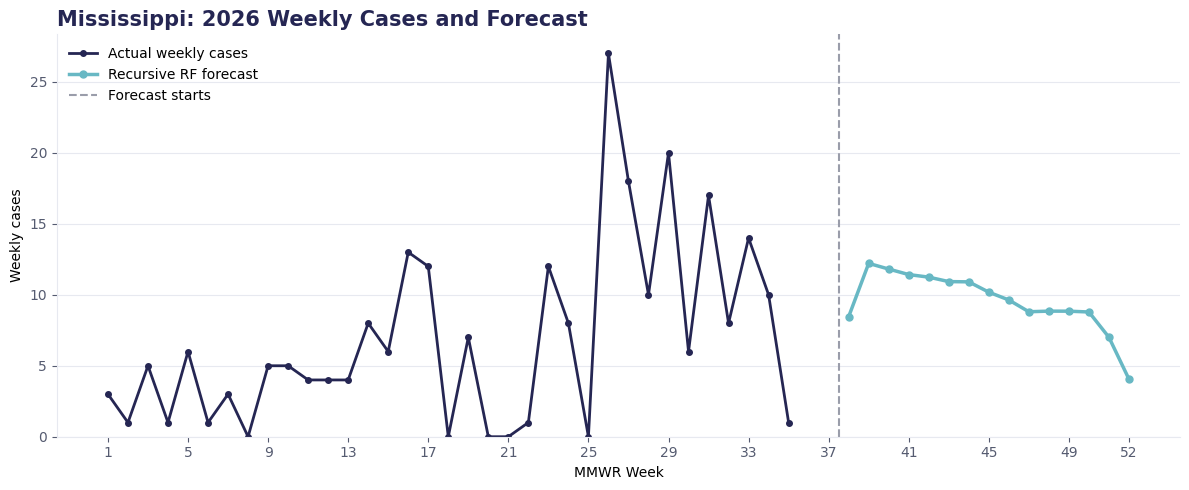

In [27]:
area_to_plot = "MISSISSIPPI"

# Get the forecast settings directly from the recursive forecast table
forecast_year = int(
    forecast["Current MMWR Year"].max()
)

first_forecast_week = int(
    forecast["MMWR WEEK"].min()
)

last_observed_week = first_forecast_week - 1

# Actual weekly cases
actual = (
    df[
        (df["Reporting Area"] == area_to_plot)
        & (df["Current MMWR Year"] == forecast_year)
        & (df["MMWR WEEK"] <= last_observed_week)
    ]
    .sort_values("MMWR WEEK")
)

# Recursive Random Forest forecast
future = (
    forecast[
        forecast["Reporting Area"] == area_to_plot
    ]
    .sort_values("MMWR WEEK")
)

if actual.empty:
    raise ValueError(
        f"No actual data found for {area_to_plot}"
    )

if future.empty:
    raise ValueError(
        f"No forecast found for {area_to_plot}"
    )

fig, ax = plt.subplots(figsize=(12, 5))

# Actual weekly cases
ax.plot(
    actual["MMWR WEEK"],
    actual["Current week"],
    color="#252653",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Actual weekly cases",
)

# Recursive forecast
ax.plot(
    future["MMWR WEEK"],
    future["Forecast Current week"],
    color="#68B8C4",
    marker="o",
    markersize=5,
    linewidth=2.5,
    label="Recursive RF forecast",
)

# Mark where forecasting begins
ax.axvline(
    last_observed_week + 0.5,
    color="#9A9DAA",
    linestyle="--",
    linewidth=1.5,
    label="Forecast starts",
)

# Title and labels
ax.set_title(
    f"{area_to_plot.title()}: {forecast_year} Weekly Cases and Forecast",
    loc="left",
    fontsize=15,
    fontweight="bold",
    color="#252653",
)

ax.set_xlabel("MMWR Week")
ax.set_ylabel("Weekly cases")

# Display weeks across the full year
week_ticks = list(range(1, 53, 4))

if 52 not in week_ticks:
    week_ticks.append(52)

ax.set_xticks(week_ticks)
ax.set_ylim(bottom=0)

# Clean report styling
ax.grid(
    axis="y",
    color="#E7E9F0",
    linewidth=0.8,
)

ax.grid(axis="x", visible=False)

ax.spines[["top", "right"]].set_visible(False)

ax.spines[["left", "bottom"]].set_color(
    "#E7E9F0"
)

ax.tick_params(colors="#555B70")

ax.legend(
    frameon=False,
    loc="upper left",
)

plt.tight_layout()
plt.show()

## 13. What happens when the forecast goes multiple weeks into the future?

The first forecast is relatively straightforward:

`Week 37 actual → Week 38 forecast`

But then:

`Week 38 forecast → Week 39 forecast`

and:

`Week 39 forecast → Week 40 forecast`

Therefore, forecast uncertainty generally increases as the horizon becomes longer.

This is an important limitation of recursive Random Forest forecasting.


## 14. Recommended next improvements for a real project

Before deploying this model, consider:

1. **Walk-forward validation** rather than only one 2025 validation year.
2. Evaluate performance separately for each Reporting Area.
3. Compare Random Forest with a seasonal baseline.
4. Compare against ARIMA/SARIMA or another time-series model.
5. Add lag features such as:
   - 2-week lag
   - 3-week lag
   - 4-week lag
   - 52-week lag
6. Add rolling statistics calculated only from previous weeks:
   - 4-week mean
   - 8-week mean
   - 12-week mean
   - 52-week mean
7. Consider a count-oriented model if the target is strongly count-distributed.
8. Produce prediction intervals or uncertainty estimates rather than only point forecasts.


In [28]:
## Final Evaluation — Recursive Random Forest

area_to_plot = "MISSISSIPPI"

# Keep ALABAMA's recursive forecast
area_final = (
    forecast[
        forecast["Reporting Area"] == area_to_plot
    ]
    .sort_values("MMWR WEEK")
    .copy()
)

if area_final.empty:
    raise ValueError(f"No forecast found for {area_to_plot}")

# Beginning and final forecast values
starting_value = area_final["Forecast Current week"].iloc[0]
final_value = area_final["Forecast Current week"].iloc[-1]

# Calculate the change
delta = final_value - starting_value

if starting_value != 0:
    percent_change = (delta / starting_value) * 100
else:
    percent_change = np.nan

print(f"Reporting area: {area_to_plot}")
print(f"Beginning forecast: {starting_value:,.0f} cases")
print(f"Final forecast: {final_value:,.0f} cases")
print(f"Net change in cases: {delta:+,.0f} cases")

if pd.notna(percent_change):
    print(f"Percentage change: {percent_change:+.2f}%")
else:
    print("Percentage change: unavailable")


Reporting area: MISSISSIPPI
Beginning forecast: 8 cases
Final forecast: 4 cases
Net change in cases: -4 cases
Percentage change: -52.03%


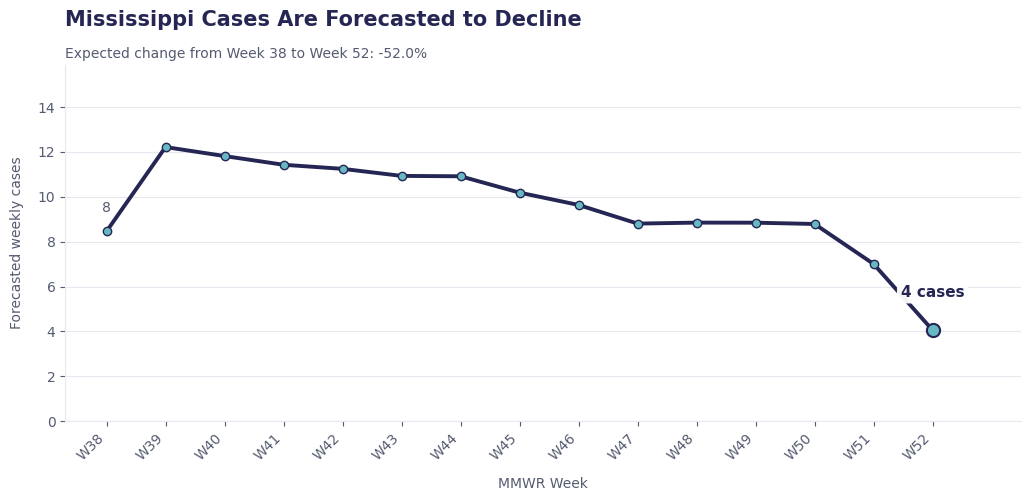

In [35]:
# Report theme
NAVY = "#252653"
CYAN = "#68B8C4"
LIGHT_GRAY = "#E7E9F0"
TEXT_GRAY = "#555B70"

# Create a title that matches the forecast direction
if delta > 0:
    direction = "Increase"
elif delta < 0:
    direction = "Decline"
else:
    direction = "Remain Stable"

fig, ax = plt.subplots(figsize=(10.5, 5.2))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Plot the recursive forecast
ax.plot(
    area_final["MMWR WEEK"],
    area_final["Forecast Current week"],
    color=NAVY,
    linewidth=2.8,
    marker="o",
    markersize=6,
    markerfacecolor=CYAN,
    markeredgecolor=NAVY,
)

# Emphasize the final forecast
ax.scatter(
    area_final["MMWR WEEK"].iloc[-1],
    final_value,
    s=90,
    color=CYAN,
    edgecolor=NAVY,
    linewidth=1.5,
    zorder=3,
)

# Label the first forecast
ax.annotate(
    f"{starting_value:,.0f}",
    xy=(
        area_final["MMWR WEEK"].iloc[0],
        starting_value,
    ),
    xytext=(0, 12),
    textcoords="offset points",
    ha="center",
    va="bottom",
    color=TEXT_GRAY,
    fontsize=10,
)

# Label the final forecast
ax.annotate(
    f"{final_value:,.0f} cases",
    xy=(
        area_final["MMWR WEEK"].iloc[-1],
        final_value,
    ),
    xytext=(0, 22),
    textcoords="offset points",
    ha="center",
    va="bottom",
    color=NAVY,
    fontsize=11,
    fontweight="bold",
    zorder=5,
    clip_on=False,
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        boxstyle="round,pad=0.25",
        alpha=0.95,
    ),
)

# Title
ax.set_title(
    f"{area_to_plot.title()} Cases Are Forecasted to {direction}",
    fontsize=15,
    fontweight="bold",
    color=NAVY,
    loc="left",
    pad=28,
)

# Subtitle
change_text = (
    f"Expected change from Week 38 to Week 52: {percent_change:+.1f}%"
    if pd.notna(percent_change)
    else "Expected change from Week 38 to Week 52: unavailable"
)

ax.text(
    0,
    1.02,
    change_text,
    transform=ax.transAxes,
    fontsize=10,
    color=TEXT_GRAY,
)

# Axis labels
ax.set_ylabel(
    "Forecasted weekly cases",
    color=TEXT_GRAY,
    labelpad=10,
)

ax.set_xlabel(
    "MMWR Week",
    color=TEXT_GRAY,
    labelpad=10,
)

# Format week labels
ax.set_xticks(
    area_final["MMWR WEEK"]
)

ax.set_xticklabels(
    [
        f"W{week}"
        for week in area_final["MMWR WEEK"]
    ],
    rotation=45,
    ha="right",
)

# Format y-axis values
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{value:,.0f}"
    )
)

# Add horizontal margins for the annotations
first_week = area_final["MMWR WEEK"].min()
last_week = area_final["MMWR WEEK"].max()

ax.set_xlim(
    first_week - 0.7,
    last_week + 1.5,
)

# Add enough vertical space for the annotations
highest_value = max(
    area_final["Forecast Current week"].max(),
    starting_value,
    final_value,
)

ax.set_ylim(
    0,
    max(highest_value * 1.30, 1),
)

# Clean styling
ax.grid(
    axis="y",
    color=LIGHT_GRAY,
    linewidth=0.8,
)

ax.grid(
    axis="x",
    visible=False,
)

ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color(LIGHT_GRAY)

ax.tick_params(
    colors=TEXT_GRAY
)

plt.tight_layout(pad=1.4)
plt.show()